The objective of this project is to predict whether a patient is likely to have heart disease based on medical attributes such as age, cholesterol level, chest pain type, and maximum heart rate. Multiple machine learning models are trained and compared to identify the most effective prediction model.

**1.Loading,Exploring & Processing Data**


In this step, the dataset is loaded and inspected to understand its structure. Missing values, duplicate records, and data types are checked to ensure data quality before model training.


In [1]:
import pandas as pd
import numpy as np

In [2]:
from google.colab import files
uploaded=files.upload()

Saving heart.csv to heart.csv


In [3]:
df=pd.read_csv('/content/heart.csv')
print(df.head())



   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [4]:
print("Rows and  Coulumns",df.shape)


Rows and  Coulumns (1025, 14)


In [5]:
print(df.info)

<bound method DataFrame.info of       age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0      52    1   0       125   212    0        1      168      0      1.0   
1      53    1   0       140   203    1        0      155      1      3.1   
2      70    1   0       145   174    0        1      125      1      2.6   
3      61    1   0       148   203    0        1      161      0      0.0   
4      62    0   0       138   294    1        1      106      0      1.9   
...   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254    0        0      159      0      0.0   
1024   54    1   0       120   188    0        1      113      0      1.4   

      slope  ca  thal  target  
0         2

In [6]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [7]:
print("Before Droping Duplicates:",df.duplicated().sum())

Before Droping Duplicates: 723


In [8]:
df=df.drop_duplicates()
print("After Droping Duplicates:",df.duplicated().sum())

After Droping Duplicates: 0


In [9]:
print(df["target"].value_counts())

target
1    164
0    138
Name: count, dtype: int64


**Decisions**
1. Missing values were checked and no null values were found.
2. Duplicate records were removed to improve data quality.
3. The target variable was separated from predictor variables.
4. The dataset was split into training and testing sets using an 80:20 ratio.
5. Feature scaling was applied because KNN and Logistic Regression are sensitive to feature magnitudes.

**2.Feature Engineering**

Feature engineering helps identify which variables contribute most to predicting heart disease. Correlation analysis and feature importance techniques are used to understand the relationship between features and the target variable.

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

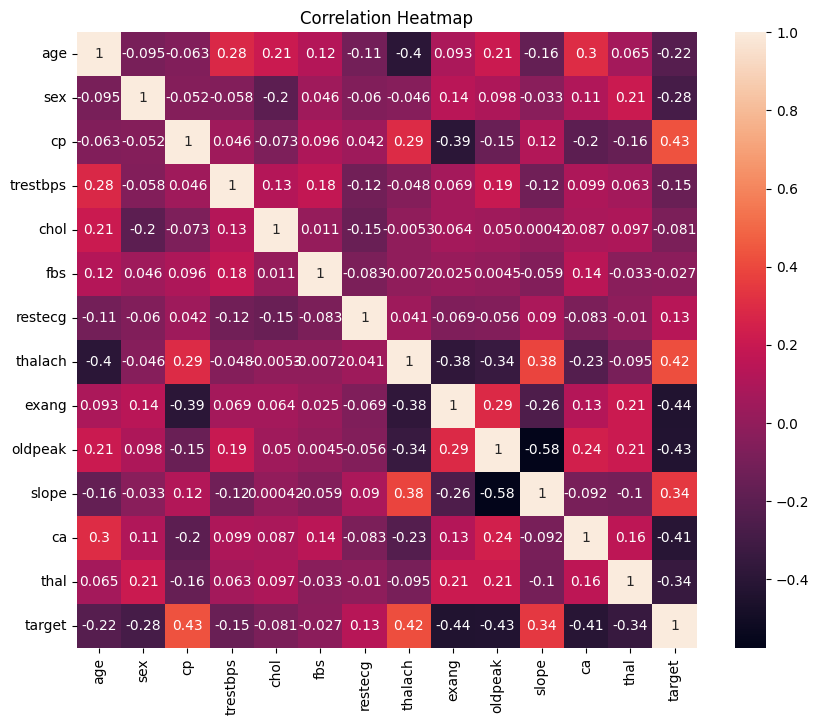

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [12]:
crr=df.corr()["target"].abs().sort_values(ascending=False)
print(crr)

target      1.000000
exang       0.435601
cp          0.432080
oldpeak     0.429146
thalach     0.419955
ca          0.408992
slope       0.343940
thal        0.343101
sex         0.283609
age         0.221476
trestbps    0.146269
restecg     0.134874
chol        0.081437
fbs         0.026826
Name: target, dtype: float64


The heatmap shows correlations between 14 heart disease variables, where light colors mean positive correlation and dark colors mean negative correlation. **Chest pain (cp = +0.43)** and **max heart rate (thalach = +0.42)** are the strongest predictors of heart disease, while **exercise angina (exang = -0.44)** and **ST depression (oldpeak = -0.43)** show the strongest negative links. The strongest overall relationship in the dataset is between **oldpeak and slope (-0.58)**.

**3.Model Building**

Three machine learning algorithms were selected for comparison:
1. Logistic Regression
2. Random Forest Classifier
3. K-Nearest Neighbors (KNN)

These algorithms were chosen because they are widely used for classification problems and provide different approaches to learning patterns from data.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
x=df.drop("target",axis=1)
y=df["target"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [15]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(x_train,y_train)
lr_pred=lr.predict(x_test)

In [16]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(random_state=42)
rf.fit(x_train,y_train)
rf_pred=rf.predict(x_test)

In [17]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)
knn_pred=knn.predict(x_test)

**4.Evaluate & Model Compare Model**

In [18]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score)

In [19]:
def evaluate_model(y_test,pred):

    return [
        accuracy_score(y_test,pred),
        precision_score(y_test,pred),
        recall_score(y_test,pred),
        f1_score(y_test,pred)
    ]

In [20]:
results = pd.DataFrame({

'Model':[
'Logistic Regression',
'Random Forest',
'KNN'
],

'Accuracy':[
accuracy_score(y_test,lr_pred),
accuracy_score(y_test,rf_pred),
accuracy_score(y_test,knn_pred)
],

'Precision':[
precision_score(y_test,lr_pred),
precision_score(y_test,rf_pred),
precision_score(y_test,knn_pred)
],

'Recall':[
recall_score(y_test,lr_pred),
recall_score(y_test,rf_pred),
recall_score(y_test,knn_pred)
],

'F1 Score':[
f1_score(y_test,lr_pred),
f1_score(y_test,rf_pred),
f1_score(y_test,knn_pred)
]

})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.770492   0.702703  0.896552  0.787879
1        Random Forest  0.836066   0.787879  0.896552  0.838710
2                  KNN  0.737705   0.696970  0.793103  0.741935


**5.Best Model Analysis**

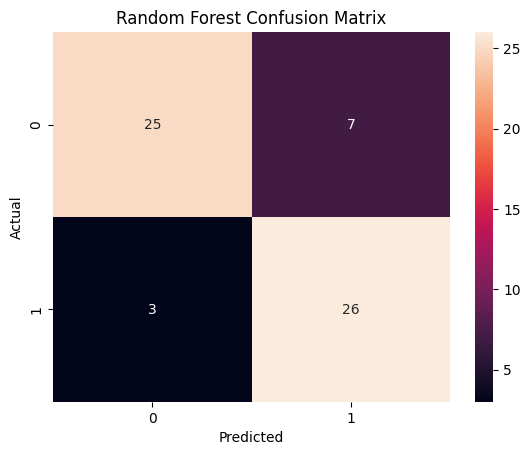

In [21]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm,annot=True,fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [22]:
print(results.sort_values(by='Accuracy',ascending=False))

                 Model  Accuracy  Precision    Recall  F1 Score
1        Random Forest  0.836066   0.787879  0.896552  0.838710
0  Logistic Regression  0.770492   0.702703  0.896552  0.787879
2                  KNN  0.737705   0.696970  0.793103  0.741935


**Random Forest Preformed Better**                                               
Random Forest is better because it combines multiple decision trees together, which reduces overfitting and improves accuracy compared to a single decision tree. It handles missing data, outliers, and high-dimensional datasets very well without much preprocessing. It also provides feature importance scores, making it interpretable while being robust for both classification and regression problems.

**Conclusion**
1. Machine learning models demonstrated strong capability in predicting heart disease based on patient medical attributes, highlighting the potential of data-driven healthcare solutions.
2. Feature analysis revealed that chest pain type, maximum heart rate (thalach), and thalassemia (thal) were among the most significant predictors of heart disease.
3. Among the three models evaluated, Random Forest delivered the best overall performance, achieving the highest accuracy and providing more robust predictions than Logistic Regression and KNN.
4. Data preprocessing, feature engineering, and feature scaling played a crucial role in improving model performance and ensuring reliable predictions.
5. The final model shows promise as a decision-support tool for early heart disease risk assessment, enabling healthcare professionals to identify high-risk patients and take preventive measures more effectively.
